# Plotting scientific data

This is a practical guide to making clean and readable plots using `Matplotlib` for:

- overall styling
- scatter plots
- bar plots
- violin plots
- line plots
- heatmaps
- 3D plots

The emphasis is not on how to make each plot, but how to make it look good. Here are some basic principles of plotting:

- increase label and tick font sizes slightly (the default values are almost always smaller than what you'd want)
- reduce visual clutter and occlusion
- use consistent line widths and marker sizes
- avoid overly saturated colors unless they serve a purpose
- prefer direct visual comparisons over decorative effects
- show uncertainty clearly but unobtrusively
- remove unnecessary spines when possible
- use grid lines sparingly and lightly

This is a good book to read if you want to learn more: https://www.edwardtufte.com/book/the-visual-display-of-quantitative-information/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
np.random.seed(0)

## 0. Overall figure features

This section shows useful controls that apply to many plots:

- axis label font sizes
- tick locations and custom tick labels
- tick direction
- titles and subtitles
- LaTeX-style math symbols
- adding or removing spines
- grid line control

These small choices can have a large effect on readability.

In [ ]:
#make a function to be used throughout the analysis for common style for figures

def style_axes(ax,
               xlabel=None,
               ylabel=None,
               title=None,
               xlim=None,
               ylim=None,
               xticks=None,
               yticks=None,
               xticklabels=None,
               yticklabels=None,
               tick_direction='out',
               rotation=0,
               spine_visibility=('top', 'right'),
               grid=False):

    # labels
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=20)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=20)
    if title is not None:
        ax.set_title(title, fontsize=20, pad=12)

    # limits
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    # ticks
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels, rotation=rotation, fontsize=12)
    if yticklabels is not None:
        ax.set_yticklabels(yticklabels, fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=16, direction=tick_direction, length=8, width=1.2)
    ax.tick_params(axis='both', which='minor', direction=tick_direction, length=3, width=1.2)

    # spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    for spine in spine_visibility:
        ax.spines[spine].set_visible(False)

    # grid
    if grid:
        ax.grid(True, alpha=0.25, linewidth=0.8)
    else:
        ax.grid(False)

    return ax

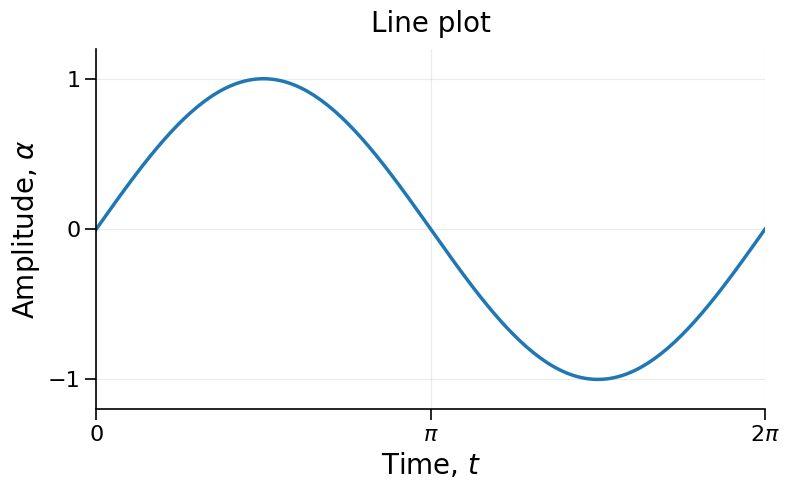

In [ ]:
x = np.linspace(0, 2*np.pi, 200) #200 points between 0 and 2pi
y = np.sin(x) #for every point of x, calculate the sine value
fig, ax = plt.subplots(figsize=(8, 5)) #control over the figure in width and height
ax.plot(x, y, linewidth=2.5)

style_axes(
    ax,
    xlabel=r'Time, $t$',
    ylabel=r'Amplitude, $\alpha$',
    title=r'Line plot',
    xlim=(0, 2*np.pi),
    ylim=(-1.2, 1.2),
    xticks=[0, np.pi, 2*np.pi],
    yticks=[-1, 0, 1],
    xticklabels=[r'$0$', r'$\pi$', r'$2\pi$'],
    tick_direction='out',
    spine_visibility=('top', 'right'),
    grid=True,
)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Use figure sizes that match the amount of information shown
- Increase label size before increasing title size too much
- Remove top and right spines unless you absolutely need them
- Keep grid lines subtle. Dark grid lines compete with the data
- Use LaTeX-style labels for mathematical quantities
- Fewer ticks are usually better

## 1.1 Scatter plot

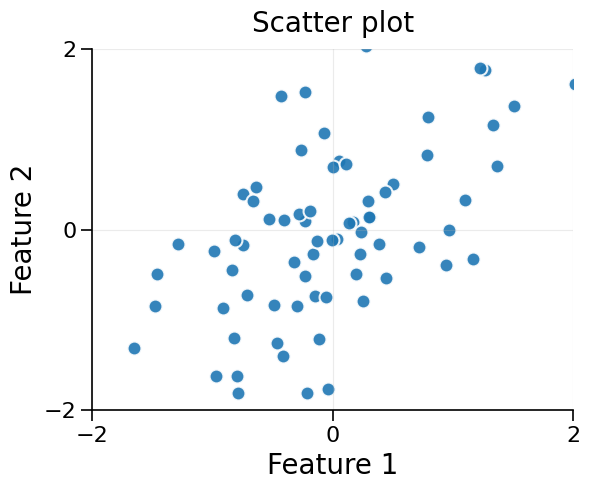

In [ ]:
n = 80
x = np.random.normal(0, 1, n)
y = 0.8*x + np.random.normal(0, 0.8, n)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, s=100, alpha=0.9, edgecolors='white', linewidths=1.5)

style_axes(ax,
           xlabel='Feature 1',
           ylabel='Feature 2',
           xlim=(-2, 2),
           ylim=(-2, 2),
           xticks=[-2, 0, 2],
           yticks=[-2, 0, 2],
           title='Scatter plot',
           spine_visibility=('top', 'right'),
           grid=True)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Use marker size large enough to be visible
- Add white edges to markers in case they overlap

## 1.2 Scatter plot with x and y errorbars

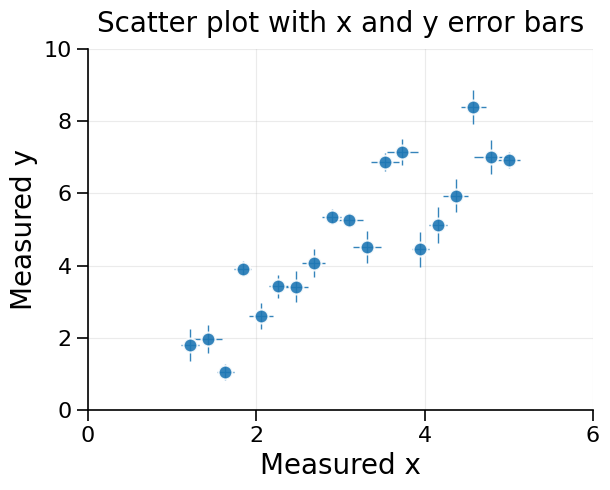

In [ ]:
n = 20
x = np.linspace(1, 5, n)
y = 1.5*x + np.random.normal(0, 1, n)
xerr = np.random.uniform(0.1, 0.2, n)
yerr = np.random.uniform(0.2, 0.5, n)

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.errorbar(x, y, xerr=xerr, yerr=yerr,
            fmt='o', markersize=10,
            elinewidth=1, capsize=0, alpha=0.9,
            markeredgecolor='white', markeredgewidth=1.5)

style_axes(ax,
           xlabel='Measured x',
           ylabel='Measured y',
           title='Scatter plot with x and y error bars',
           xlim=(0, 6),
           ylim=(0, 10),
           xticks=range(0,8,2),
           yticks=range(0,12,2),
           spine_visibility=('top', 'right'),
           grid=True)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Caps are usually unnecessary
- Avoid thick error bars. They can dominate the plot

## 2.1 Bar plot

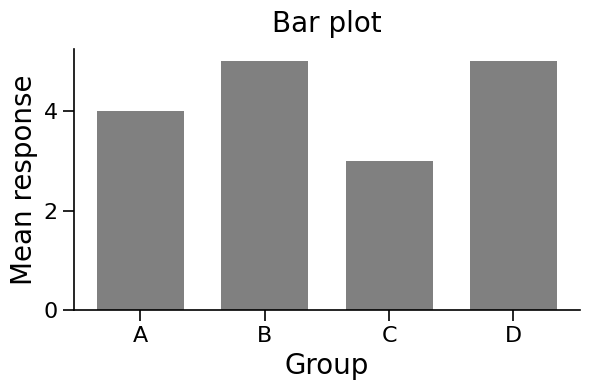

In [ ]:
labels = ['A', 'B', 'C', 'D']
values = [4, 5, 3, 5]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, values, width=0.7, color='gray')

style_axes(ax,
           xlabel='Group',
           ylabel='Mean response',
           title='Bar plot',
           xticks=x,
           xticklabels=labels,
           spine_visibility=('top', 'right'),
           grid=False)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Bars work best for a small number of categories
- Use a width that leaves a little whitespace between bars
- Avoid bars when the individual data distribution is important

## 2.2 Bar plot with errorbars

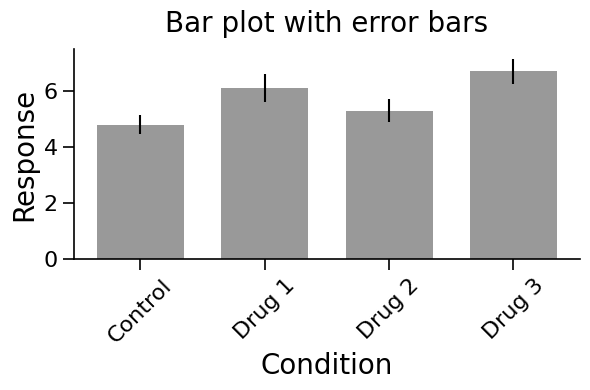

In [ ]:
labels = ['Control', 'Drug 1', 'Drug 2', 'Drug 3']
means = np.array([4.8, 6.1, 5.3, 6.7])
errs = np.array([0.35, 0.5, 0.4, 0.45])
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, means, yerr=errs, capsize=0, width=0.7, alpha=0.8, color='gray')

style_axes(ax,
           xlabel='Condition',
           ylabel='Response',
           title='Bar plot with error bars',
           xticks=x,
           xticklabels=labels,
           rotation=45,
           spine_visibility=('top', 'right'),
           grid=False)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Make sure the error bars are visible but not heavier than the bars
- Consider whether a violin plot or dot-over-bar plot would communicate the data better

## 2.3 Bar plot with errorbars with data overlaid

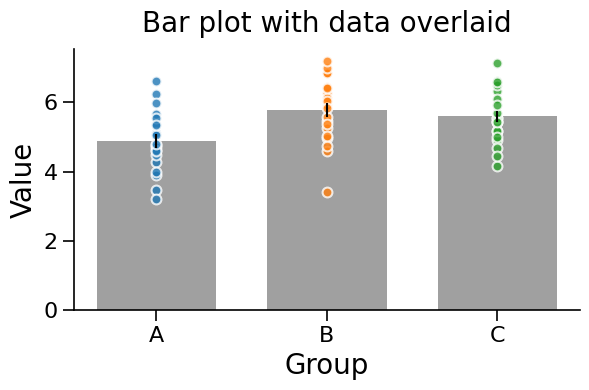

In [ ]:
labels = ['A', 'B', 'C']
data = [
    np.random.normal(5, 1, 20),
    np.random.normal(6, 1, 20),
    np.random.normal(5.5, 0.8, 20),
]
means = [d.mean() for d in data]
sems = [d.std() / np.sqrt(len(d)) for d in data]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, means, yerr=sems, capsize=0, width=0.7, alpha=0.75, color='gray')

for i, d in enumerate(data):
    # jitter = np.random.uniform(-0.1, 0.1, size=len(d))
    ax.scatter(np.full_like(d, x[i]), d, s=50, alpha=0.8, edgecolors='white', linewidths=1.5)

style_axes(ax,
           xlabel='Group',
           ylabel='Value',
           title='Bar plot with data overlaid',
           xticks=x,
           xticklabels=labels,
           spine_visibility=('top', 'right'),
           grid=False)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Overlaying raw data makes bar plots much more informative
- Keep the jitter small so categories remain visually distinct
- Use smaller points than you would in a plain scatter plot
- Remove error bars when overlaying data

## 2.4 Violin plots

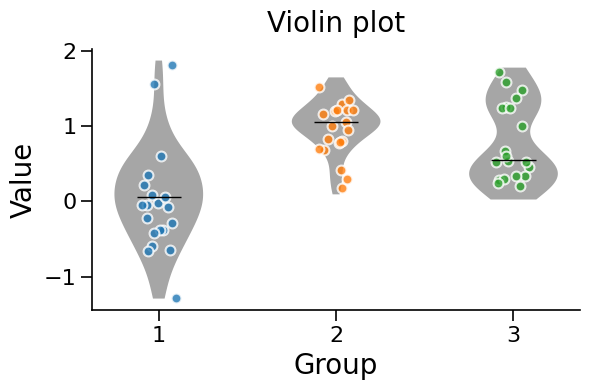

In [ ]:
data = [
    np.random.normal(0.0, 0.7, 100),
    np.random.normal(1.0, 0.35, 100),
    np.concatenate([np.random.normal(0.4, 0.2, 60), np.random.normal(1.4, 0.25, 40)])
]
labels = ['1', '2', '3']

fig, ax = plt.subplots(figsize=(6, 4))
parts = ax.violinplot(data, showmeans=False, showmedians=True, showextrema=False)
for i, d in enumerate(data):
    jitter = np.random.uniform(-0.1, 0.1, size=len(d))
    ax.scatter(np.full_like(d, x[i]+1)[::5] + jitter[::5], d[::5], s=50, alpha=0.8, edgecolors='white', linewidths=1.5)

for body in parts['bodies']:
    body.set_facecolor('gray')
    # body.set_edgecolor('black')
    body.set_alpha(0.7)

parts['cmedians'].set_linewidth(1)
parts['cmedians'].set_color('black')

style_axes(ax,
           xlabel='Group',
           ylabel='Value',
           title='Violin plot',
           xticks=np.arange(1, len(labels)+1),
           xticklabels=labels,
           spine_visibility=('top', 'right'),
           grid=False)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Violin plots are a useful way to show the shape of the data distribution
- Include a median or quartile indicator so the center is easy to read
- Use them carefully with small sample sizes because the smoothing can be misleading

## 3.1 Line plot

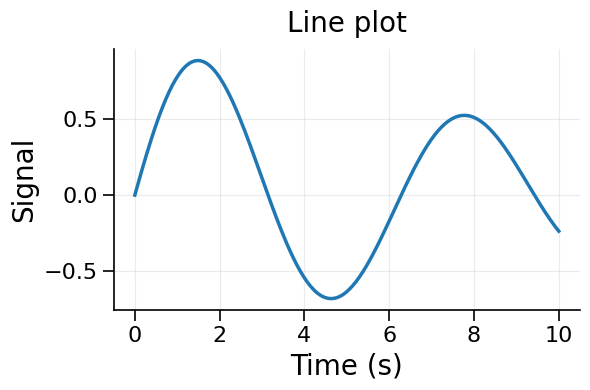

In [ ]:
x = np.linspace(0, 10, 250)
y = np.sin(x) * np.exp(-x/12)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, linewidth=2.5)

style_axes(ax,
           xlabel='Time (s)',
           ylabel='Signal',
           title='Line plot',
           spine_visibility=('top', 'right'),
           grid=True)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Use lines thick enough to survive resizing
- Avoid too many overlapping traces unless they are clearly distinguishable

## 3.2 Line plot with regular errorbars

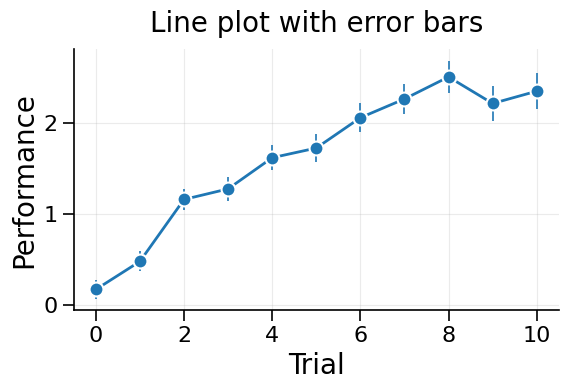

In [ ]:
x = np.arange(0, 11)
y = np.log1p(x) + 0.2*np.random.randn(len(x))
err = np.linspace(0.1, 0.2, len(x))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(x, y, yerr=err, fmt='-o',
            linewidth=2, markersize=10,
            elinewidth=1.2, capsize=0, markeredgecolor='white', markeredgewidth=1.5)

style_axes(ax,
           xlabel='Trial',
           ylabel='Performance',
           title='Line plot with error bars',
           spine_visibility=('top', 'right'),
           grid=True)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Markers can draw focus to the data
- Use regular error bars when the number of x positions is small or moderate
- For dense x values, markers and bars can become cluttered. Shaded bands often look better

## 3.3 Line plot with shaded errorbars

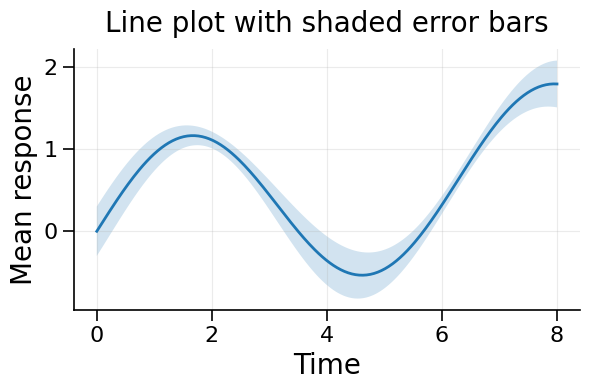

In [ ]:
x = np.linspace(0, 8, 250)
mean = np.sin(x) + 0.1*x
err = 0.2 + 0.1*np.cos(1.5*x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, mean, linewidth=2)
ax.fill_between(x, mean-err, mean+err, alpha=0.2)

style_axes(ax,
           xlabel='Time',
           ylabel='Mean response',
           title='Line plot with shaded error bars',
           spine_visibility=('top', 'right'),
           grid=True)
plt.tight_layout()
plt.show()

### Aesthetic suggestions

- Shaded error bars are often best for dense or continuous curves
- Keep the band transparent enough that the mean line stays dominant

## 4. Heatmaps for correlation matrices and color schemes

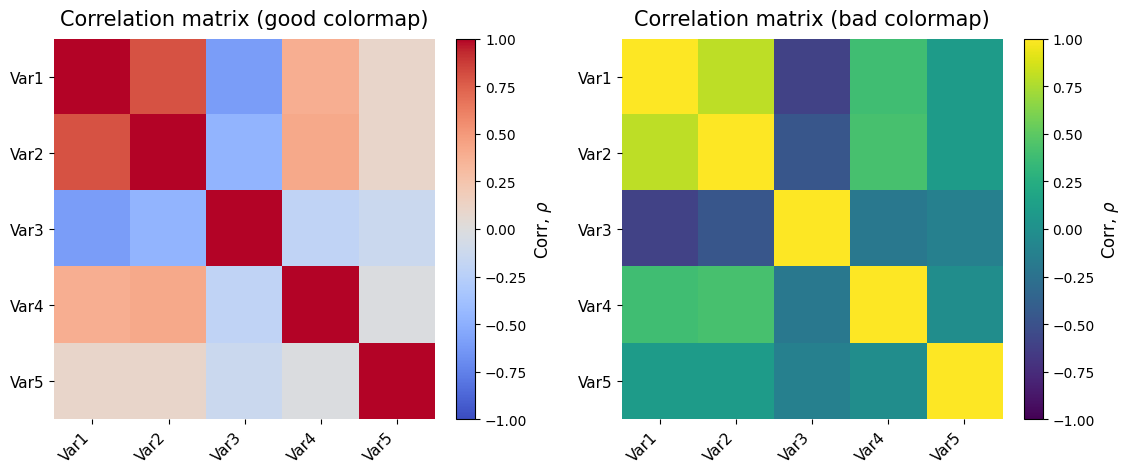

In [ ]:
# Simulate data with structured correlations
n = 250
z1 = np.random.normal(size=n)
z2 = 0.7*z1 + np.random.normal(scale=0.6, size=n)
z3 = -0.5*z1 + np.random.normal(scale=0.7, size=n)
z4 = 0.4*z2 + np.random.normal(scale=0.7, size=n)
z5 = np.random.normal(size=n)

X = np.column_stack([z1, z2, z3, z4, z5])
corr = np.corrcoef(X, rowvar=False)

labels = ['Var1', 'Var2', 'Var3', 'Var4', 'Var5']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# Good colormap choice
im0 = axes[0].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[0].set_title('Correlation matrix (good colormap)', fontsize=15, pad=10)
axes[0].set_xticks(range(len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
axes[0].set_yticklabels(labels, fontsize=11)

cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.05, pad=0.05)
cbar0.ax.set_ylabel(r'Corr, $\rho$', fontsize=12)

# Bad colormap choice
im1 = axes[1].imshow(corr, vmin=-1, vmax=1, cmap='viridis')
axes[1].set_title('Correlation matrix (bad colormap)', fontsize=15, pad=10)
axes[1].set_xticks(range(len(labels)))
axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
axes[1].set_yticklabels(labels, fontsize=11)

cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.05, pad=0.05)
cbar1.ax.set_ylabel(r'Corr, $\rho$', fontsize=12)

for ax in axes:
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Aesthetic suggestions for heatmaps

- Use a diverging colormap for quantities centered around zero, like correlations
- Use a sequential colormap for strictly positive or negative quantities
- Label colorbars
- Rotate x tick labels when needed
- Color choice changes interpretation, so choose it intentionally

## 5. Scatter plots and line plots in 3D

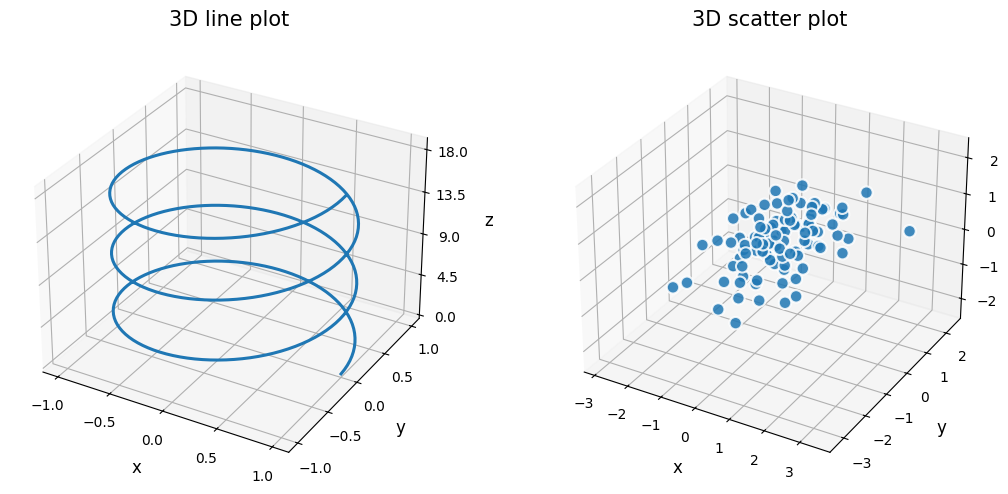

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

t = np.linspace(0, 6*np.pi, 300)
x = np.cos(t)
y = np.sin(t)
z = t

xs = np.random.normal(0, 1, 100)
ys = np.random.normal(0, 1, 100)
zs = 0.5*xs - 0.2*ys + np.random.normal(0, 0.7, 100)

fig = plt.figure(figsize=(11, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x, y, z, linewidth=2.2)
ax1.set_title('3D line plot', fontsize=15, pad=12)
ax1.set_xlabel('x', fontsize=12, labelpad=8)
ax1.set_ylabel('y', fontsize=12, labelpad=8)
ax1.set_zlabel('z', fontsize=12, labelpad=8)
ax1.set_xticks(np.linspace(-1, 1, 5))
ax1.set_yticks(np.linspace(-1, 1, 5))
ax1.set_zticks(np.linspace(0, 18, 5))
ax1.tick_params(labelsize=10)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(xs, ys, zs, s=80, alpha=0.85, edgecolors='white', linewidths=1.5)
ax2.set_title('3D scatter plot', fontsize=15, pad=12)
ax2.set_xlabel('x', fontsize=12, labelpad=8)
ax2.set_ylabel('y', fontsize=12, labelpad=8)
ax2.set_zlabel('z', fontsize=12, labelpad=8)
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

### Aesthetic suggestions for 3D plots

- Use 3D only when the third dimension is genuinely informative
- 3D plots can look attractive but often make precise comparison harder
- Keep viewing angles simple and axis labels clear

## Optional global style block

If you want a consistent look across the whole notebook, you can also set global Matplotlib defaults

In [ ]:
plt.rcParams.update({
    'figure.figsize': (6, 4.5),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.2,
    'lines.markersize': 6,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
})

## Summary: practical defaults for good-looking plots

Across most scientific figures, these defaults work well:

- remove top and right spines
- use font sizes larger than 14
- keep grid lines faint or remove them
- use line widths around 2 for line plots
- draw edges around data points when they overlap
- show raw data whenever possible
- use shaded error bars for dense curves
- choose colormaps based on the meaning of the data

**Plots look good when the data are easy to read**